# Regresión lineal · Regresión logística · k-NN

### Una sola idea, tres modelos

<br>

*120 minutos*

# La agenda de hoy

| # | Tema | Tiempo |
|---|------|--------|
| 1 | Aprendizaje supervisado: el mapa | 10' |
| 2 | Regresión lineal | 20' |
| 3 | **Descenso por el gradiente** | 30' |
| 4 | Regresión logística | 25' |
| 5 | k-NN (el que no aprende parámetros) | 20' |
| 6 | Cierre + desafío integrador | 20' |

**Todo con el mismo conjunto de datos.** Un solo ejemplo que nos va a acompañar de punta a punta.

In [55]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 100,
    "font.size": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

C_DATOS = "#1f77b4"
C_MODELO = "#d62728"
C_APRUEBA = "#2ca02c"
C_NO = "#d62728"
C_EXTRA = "#ff7f0e"
CMAP_CLASES = ListedColormap([C_NO, C_APRUEBA])

In [56]:
# ------------------------------------------------------------------
# Nuestro dataset: 120 alumnos de una materia
# ------------------------------------------------------------------
N = 120

horas_estudio = rng.uniform(0, 20, N)     # horas de estudio por semana
asistencia = rng.uniform(40, 100, N)      # % de clases a las que asistió

# La "verdad" que generó los datos. El modelo tendrá que redescubrirla.
THETA_REAL = (0.5, 0.28, 0.040)

nota = (THETA_REAL[0]
        + THETA_REAL[1] * horas_estudio
        + THETA_REAL[2] * asistencia
        + rng.normal(0, 0.8, N))          # el mundo tiene ruido

alumnos = pd.DataFrame({
    "horas_estudio": horas_estudio.round(2),
    "asistencia": asistencia.round(1),
    "nota": np.clip(nota, 0, 10).round(2),
})
alumnos["aprueba"] = (alumnos.nota >= 6).astype(int)

FEATURES = ["horas_estudio", "asistencia"]
X = alumnos[FEATURES].to_numpy()
X_horas = alumnos[["horas_estudio"]].to_numpy()
y_nota = alumnos.nota.to_numpy()
y_aprueba = alumnos.aprueba.to_numpy()

# Nota: las dos variables tienen escalas MUY distintas (0-20 vs 40-100).
# Eso no es casualidad, lo vamos a necesitar más adelante.

In [57]:
# ------------------------------------------------------------------
# Helpers de ploteo (para no repetir código en cada slide)
# ------------------------------------------------------------------
def plot_alumnos(x="horas_estudio", y="nota", ax=None, datos=None, **kw):
    datos = alumnos if datos is None else datos
    if ax is None:
        _, ax = plt.subplots()
    ax.scatter(datos[x], datos[y], c=C_DATOS, alpha=0.7, edgecolor="white", **kw)
    ax.set_xlabel(x.replace("_", " "))
    ax.set_ylabel(y)
    return ax


def plot_clases(ax=None, X_=None, y_=None,
                xlabel="horas de estudio", ylabel="% de asistencia"):
    if ax is None:
        _, ax = plt.subplots()
    X_ = X if X_ is None else X_
    y_ = y_aprueba if y_ is None else y_
    for clase, color, etiqueta in [(0, C_NO, "no aprueba"), (1, C_APRUEBA, "aprueba")]:
        m = y_ == clase
        ax.scatter(X_[m, 0], X_[m, 1], c=color, label=etiqueta,
                   alpha=0.75, edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc="lower right")
    return ax


def plot_frontera(predict, ax, alpha=0.15):
    '''Pinta la región de decisión de cualquier predict(X de 2 columnas) -> 0/1.'''
    gx, gy = np.meshgrid(np.linspace(-1, 21, 220), np.linspace(35, 105, 220))
    Z = np.asarray(predict(np.c_[gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=[-0.5, 0.5, 1.5],
                colors=[C_NO, C_APRUEBA], alpha=alpha)
    ax.set_xlim(-1, 21)
    ax.set_ylim(35, 105)
    return ax


def agregar_bias(A):
    '''[x1, x2] -> [1, x1, x2], para poder escribir h = X @ theta.'''
    A = np.atleast_2d(np.asarray(A, dtype=float))
    return np.c_[np.ones(len(A)), A]


def estandarizar(A, mu=None, sd=None):
    mu = A.mean(axis=0) if mu is None else mu
    sd = A.std(axis=0) if sd is None else sd
    return (A - mu) / sd, mu, sd

# El hilo conductor: nuestros alumnos

Tenemos datos de **120 alumnos** de una materia:

| variable | qué es | rango |
|---|---|---|
| `horas_estudio` | horas de estudio por semana | 0 – 20 |
| `asistencia` | % de clases a las que asistió | 40 – 100 |
| `nota` | nota final | 0 – 10 |
| `aprueba` | 1 si `nota >= 6` | 0 / 1 |

In [58]:
display(alumnos.head(8))
alumnos.describe().round(2)

,horas_estudio,asistencia,nota,aprueba
0,15.48,75.0,7.25,1
1,8.78,79.0,5.59,0
2,17.17,45.1,5.39,0
3,13.95,64.9,6.87,1
4,1.88,42.5,1.88,0
5,19.51,69.6,8.33,1
6,15.22,59.8,6.45,1
7,15.72,48.7,6.77,1


,horas_estudio,asistencia,nota,aprueba
count,120.00,120.00,120.00,120.00
mean,9.97,69.25,6.07,0.57
std,5.47,18.07,2.02,0.50
min,0.15,40.80,1.66,0.00
25%,5.41,51.95,4.62,0.00
50%,9.41,69.50,6.22,1.00
75%,14.56,85.20,7.53,1.00
max,19.51,99.50,10.00,1.00


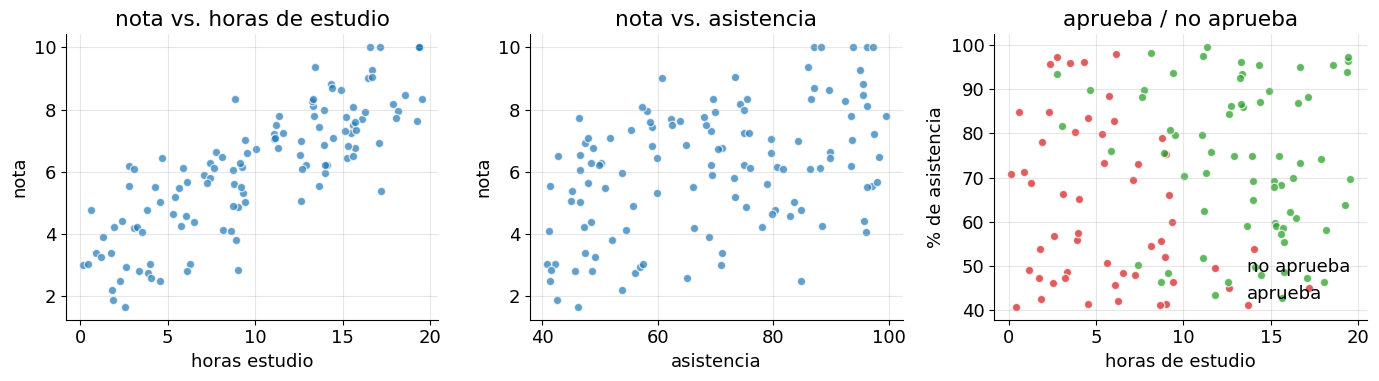

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_alumnos("horas_estudio", "nota", ax=axes[0])
axes[0].set_title("nota vs. horas de estudio")

plot_alumnos("asistencia", "nota", ax=axes[1])
axes[1].set_title("nota vs. asistencia")

plot_clases(ax=axes[2])
axes[2].set_title("aprueba / no aprueba")

plt.tight_layout()

# Las tres preguntas de hoy

Mismos alumnos, mismos ejes, tres preguntas distintas:

1. **¿Qué nota va a sacar?** → un número → **regresión lineal**
2. **¿Aprueba o no?** → una clase → **regresión logística**
3. **¿A qué alumnos se parece?** → los vecinos → **k-NN**

<br>

*Al final de la clase vas a poder responder las tres con el mismo dataset, y sobre todo saber **por qué** elegirías cada una.*

# 1. Aprendizaje supervisado

## El mapa

*10 minutos*

# Supervisado = tenemos las respuestas

Tenemos **pares** (entrada, salida correcta), y queremos aprender la función que los conecta.

### Regresión (la salida es un número)
- Valor de una propiedad
- Cotización de una acción
- Cantidad de productos comprados
- **La nota final de un alumno**

### Clasificación (la salida es una categoría)
- Email: spam / no spam
- Tweet: positivo / negativo
- **Alumno: aprueba / desaprueba**

#### Por convención, las clases se codifican 1 / 0

# La anatomía del problema

$$ x = \begin{bmatrix} horas\_estudio \\ asistencia \end{bmatrix} \qquad y = nota $$

Buscamos una función $h_\theta$ (la **hipótesis**) tal que:

$$ h_\theta(x) \approx y $$

- $x$ → las **entradas** (features)
- $y$ → la **salida** que queremos predecir (target)
- $\theta$ → los **parámetros**: lo que el modelo tiene que encontrar
- $m$ → cantidad de ejemplos (acá, 120)

**Entrenar** = encontrar $\theta$. &nbsp;&nbsp; **Predecir** = evaluar $h_\theta$ en un $x$ nuevo.

# Entrenar es probar candidatos

Sospechamos que la relación tiene forma de **recta**. Probamos muchas, y nos quedamos con la que mejor se ajusta.

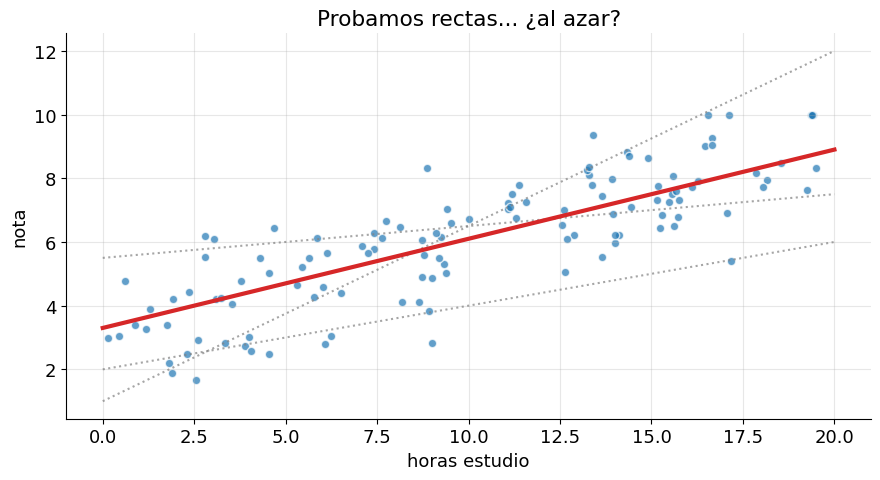

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_alumnos(ax=ax)

grilla = np.linspace(0, 20, 50)
for pendiente, corte, estilo in [(0.10, 5.5, ":"), (0.55, 1.0, ":"),
                                 (0.20, 2.0, ":"), (0.28, 3.3, "-")]:
    es_la_buena = estilo == "-"
    ax.plot(grilla, corte + pendiente * grilla,
            ls=estilo, lw=3 if es_la_buena else 1.5,
            c=C_MODELO if es_la_buena else "gray",
            alpha=1 if es_la_buena else 0.7)

ax.set_title("Probamos rectas... ¿al azar?")
plt.tight_layout()

# Lo importante: el conocimiento queda en los parámetros

Una vez entrenado, para predecir **no necesitamos los datos**. Solo la función:

$$ h_\theta(x) = 3.3 + 0.28 \cdot horas\_estudio $$

El **3.3** y el **0.28** *son* el modelo. Se guardan en un archivo de unos pocos bytes y con eso predecís para siempre.

<br>

**Ojo con esto**, porque al final de la clase vamos a ver un modelo (k-NN) que rompe esta idea por completo: no tiene parámetros, y para predecir necesita **todos los datos**.

# 2. Regresión lineal

*20 minutos*

# ¿Por qué? ¿Cuándo?

* Sirve para hacer **regresión** (ORLY).
* Cuando sospechamos que la salida depende de las entradas de manera **lineal**.
* Si no es lineal, va a funcionar **muy mal**.
* Es **rapidísima** y **simple**.
* Permite **explicar** los resultados (vamos a volver a esto).

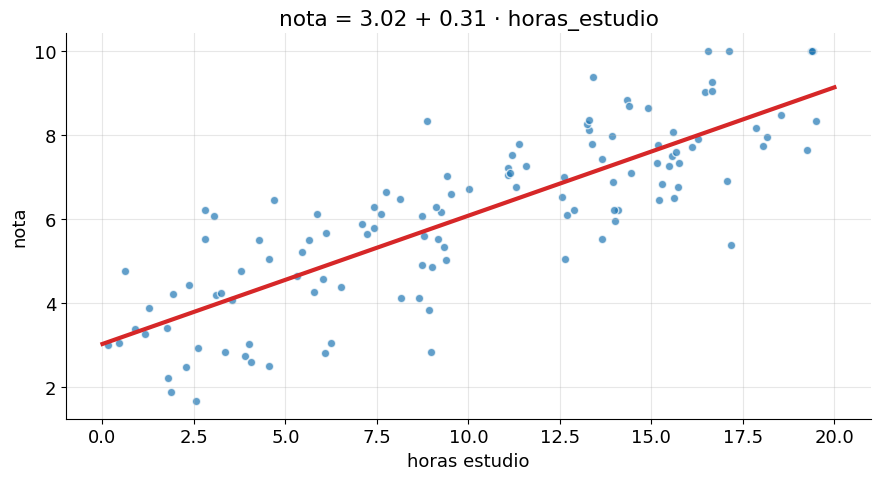

In [61]:
from sklearn.linear_model import LinearRegression

# Por ahora usamos sklearn como caja negra: queremos ver la forma del resultado.
modelo = LinearRegression().fit(X_horas, y_nota)

fig, ax = plt.subplots(figsize=(9, 5))
plot_alumnos(ax=ax)
grilla = np.linspace(0, 20, 100).reshape(-1, 1)
ax.plot(grilla, modelo.predict(grilla), c=C_MODELO, lw=3)
ax.set_title("nota = {:.2f} + {:.2f} · horas_estudio".format(
    modelo.intercept_, modelo.coef_[0]))
plt.tight_layout()

# Múltiples entradas

Con una sola entrada:

$$ h_\theta(x) = \theta_0 + \theta_1 x_1 $$

Con las dos que tenemos:

$$ h_\theta(x) = \theta_0 + \theta_1 \cdot horas\_estudio + \theta_2 \cdot asistencia $$

En general: **un parámetro por cada entrada, más uno suelto** ($\theta_0$, el *intercept* o *bias*).

$$ h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n $$

# La forma vectorial

Si agregamos un $x_0 = 1$ fijo a cada ejemplo, todo se escribe de una sola manera:

$$ h_\theta(x) = \theta^T x = \begin{bmatrix} \theta_0 & \theta_1 & \theta_2 \end{bmatrix} \begin{bmatrix} 1 \\ x_1 \\ x_2 \end{bmatrix} $$

En numpy, literalmente:

```python
h = X @ theta
```

**Esta notación nos va a servir para los dos modelos de hoy.** Guardala.

# ¿Cómo elegimos $\theta$?

Probar rectas al azar es una locura.

Primero necesitamos poder **medir qué tan mal** anda una recta. Eso es la **función de error** (o de costo).

In [62]:
def calcular_error(p1):
    '''Qué tan mal predice la recta  nota = p1 * horas_estudio.'''

    # la función que estamos probando
    def f(horas):
        return p1 * horas

    # medimos qué tan lejos cae de cada alumno real
    error = 0
    for horas, nota_real in zip(alumnos.horas_estudio, alumnos.nota):
        error += abs(f(horas) - nota_real)

    return error / len(alumnos)   # error promedio por alumno

In [63]:
for p1 in [0, 100, 2, 0.5, 0.44]:
    print("p1 = {:>6}  ->  error medio = {:.3f}".format(p1, calcular_error(p1)))

p1 =      0  ->  error medio = 6.069
p1 =    100  ->  error medio = 991.397
p1 =      2  ->  error medio = 14.100
p1 =    0.5  ->  error medio = 1.544
p1 =   0.44  ->  error medio = 1.802


# Del valor absoluto al error cuadrático

Usamos `abs()`, pero en la práctica se usa el **error cuadrático medio**:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \frac{1}{2}\left(h_\theta(x^i) - y^i\right)^2 $$

¿Por qué?

* Es **derivable en todo punto** (el valor absoluto no lo es en 0) — y las derivadas son lo que va a hacer funcionar todo el bloque siguiente.
* **Castiga más** los errores grandes.
* El $\frac{1}{2}$ está solo para que la derivada quede prolija (se cancela con el cuadrado).

In [64]:
def h_lineal(theta, X_):
    '''La hipótesis: una combinación lineal de las entradas.'''
    return X_ @ theta


def J_mse(theta, X_, y_):
    '''Error cuadrático medio (dividido 2).'''
    return np.mean((h_lineal(theta, X_) - y_) ** 2) / 2


# La misma cuenta que antes, ahora vectorizada y en versión cuadrática
print("J con theta1 = 0.44 :", round(J_mse(np.array([0.44]), X_horas, y_nota), 4))
print("J con theta1 = 0.60 :", round(J_mse(np.array([0.60]), X_horas, y_nota), 4))

J con theta1 = 0.44 : 2.3278
J con theta1 = 0.60 : 1.9396


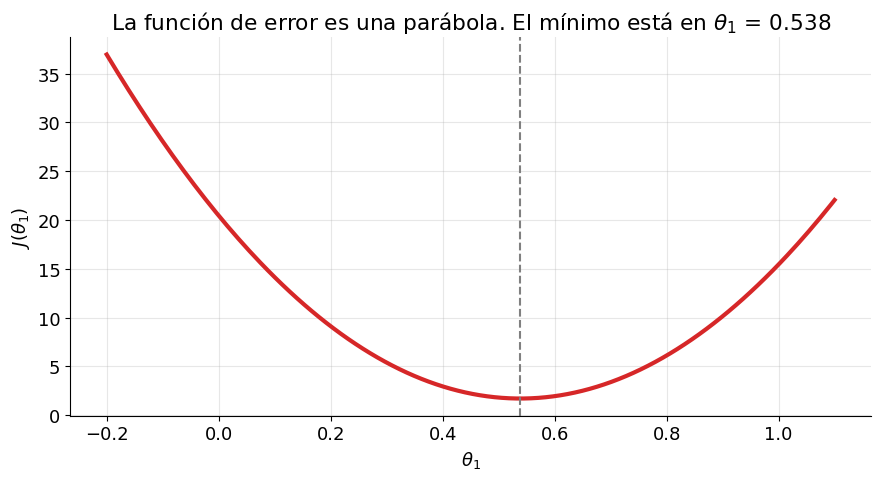

In [65]:
# ¿Qué forma tiene J si movemos UN solo parámetro?
thetas = np.linspace(-0.2, 1.1, 200)
costos = [J_mse(np.array([t]), X_horas, y_nota) for t in thetas]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thetas, costos, c=C_MODELO, lw=3)
mejor = thetas[int(np.argmin(costos))]
ax.axvline(mejor, ls="--", c="gray")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$J(\theta_1)$")
ax.set_title(r"La función de error es una parábola. El mínimo está en $\theta_1$ = {:.3f}".format(mejor))
plt.tight_layout()

**Encontrar el mejor $\theta$ es encontrar el punto más bajo de esta curva.**

Y con dos parámetros, el punto más bajo de una superficie.

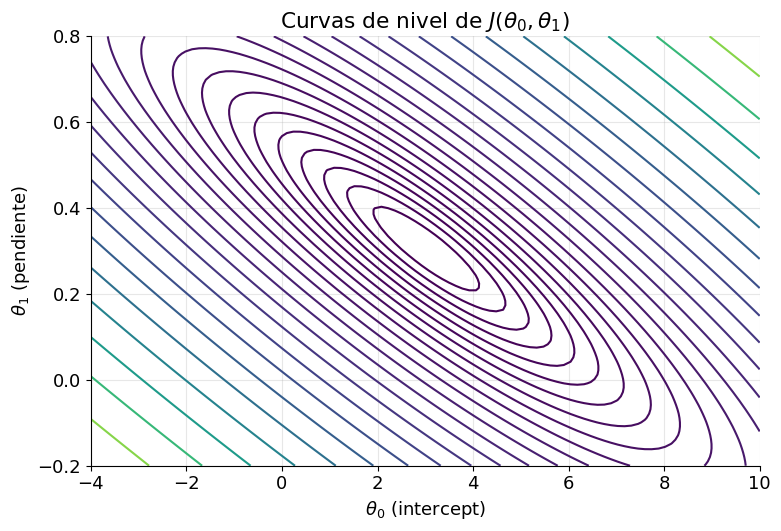

In [66]:
def malla_costo(rango0, rango1, X_, y_, costo=J_mse, n=100):
    t0 = np.linspace(*rango0, n)
    t1 = np.linspace(*rango1, n)
    T0, T1 = np.meshgrid(t0, t1)
    Z = np.array([costo(np.array([a, b]), X_, y_)
                  for a, b in zip(T0.ravel(), T1.ravel())]).reshape(T0.shape)
    return T0, T1, Z


Xb_horas = agregar_bias(X_horas)          # ahora sí, con el theta_0
T0, T1, Z = malla_costo((-4, 10), (-0.2, 0.8), Xb_horas, y_nota)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.contour(T0, T1, Z, levels=np.geomspace(Z.min(), Z.max(), 25), cmap="viridis")
ax.set_xlabel(r"$\theta_0$ (intercept)")
ax.set_ylabel(r"$\theta_1$ (pendiente)")
ax.set_title("Curvas de nivel de $J(\\theta_0, \\theta_1)$")
plt.tight_layout()

Es un **valle**. Queremos llegar al fondo.

Fijate que es un valle **alargado**: eso nos va a traer problemas en un rato.

# 3. Descenso por el gradiente

## El corazón de la clase

*30 minutos*

# ¿Y cómo bajamos al fondo del valle?

Probar valores al azar es una locura: con 2 parámetros ya es un plano infinito, y los modelos de verdad tienen millones.

Claramente tiene que haber una forma **inteligente** de elegir el próximo candidato.

La función de error es una **función matemática**. Se le pueden calcular **derivadas**.

Y la derivada nos dice **para qué lado está la bajada**.

# Derivemos, con paciencia

$$ J(\theta) = \frac{1}{m}\sum_{i=1}^{m} \frac{1}{2}\left(h_\theta(x^i) - y^i\right)^2 \qquad h_\theta(x) = \theta^T x $$

Derivamos respecto de **un** parámetro $\theta_j$ (derivada parcial), aplicando la regla de la cadena:

$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m} \frac{1}{2} \cdot 2\left(h_\theta(x^i) - y^i\right) \cdot \frac{\partial}{\partial \theta_j}\left(h_\theta(x^i) - y^i\right) $$

Y como $\frac{\partial}{\partial \theta_j} \theta^T x = x_j$ (los demás términos no dependen de $\theta_j$):

$$ \boxed{\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^i) - y^i\right)x_j^i} $$

*(ahí se ve para qué servía el $\frac{1}{2}$)*

# La regla de actualización

$$ \min_\theta J(\theta): $$

Repetir {

$$ \quad \theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta) $$

}

* El **signo menos**: la derivada apunta hacia donde el error *sube*, así que vamos al revés.
* $\alpha$ es el **learning rate**: qué tan grande es el paso. Ya vamos a sufrirlo.
* Todos los $\theta_j$ se actualizan **a la vez**, con los valores viejos.

En forma vectorial, las tres líneas se vuelven una: $\quad \theta := \theta - \frac{\alpha}{m} X^T (X\theta - y)$

In [67]:
def grad_mse(theta, X_, y_):
    '''El gradiente que acabamos de derivar, en una línea.'''
    return X_.T @ (h_lineal(theta, X_) - y_) / len(y_)


def descenso_gradiente(X_, y_, costo, gradiente,
                       alpha=0.01, n_iters=500, theta_ini=None):
    '''Descenso por el gradiente, desde cero. Sirve para CUALQUIER
    par (costo, gradiente): ese es todo el truco de la clase de hoy.'''
    theta = np.zeros(X_.shape[1]) if theta_ini is None else np.array(theta_ini, float)

    hist_theta = [theta.copy()]
    hist_costo = [costo(theta, X_, y_)]

    for _ in range(n_iters):
        theta = theta - alpha * gradiente(theta, X_, y_)   # <-- el algoritmo entero
        hist_theta.append(theta.copy())
        hist_costo.append(costo(theta, X_, y_))

    return theta, np.array(hist_theta), np.array(hist_costo)

## Probémoslo con un solo parámetro

$h_\theta(x) = \theta_1 \cdot horas\_estudio$ — así podemos **ver** el camino sobre la parábola.

In [68]:
theta_fin, camino, costos_iter = descenso_gradiente(
    X_horas, y_nota, J_mse, grad_mse,
    alpha=0.005, n_iters=30, theta_ini=[0.05],
)

print("theta_1 al terminar :", round(theta_fin[0], 4))
print("J al empezar        :", round(costos_iter[0], 4))
print("J al terminar       :", round(costos_iter[-1], 4))

theta_1 al terminar : 0.5388
J al empezar        : 17.1321
J al terminar       : 1.6974


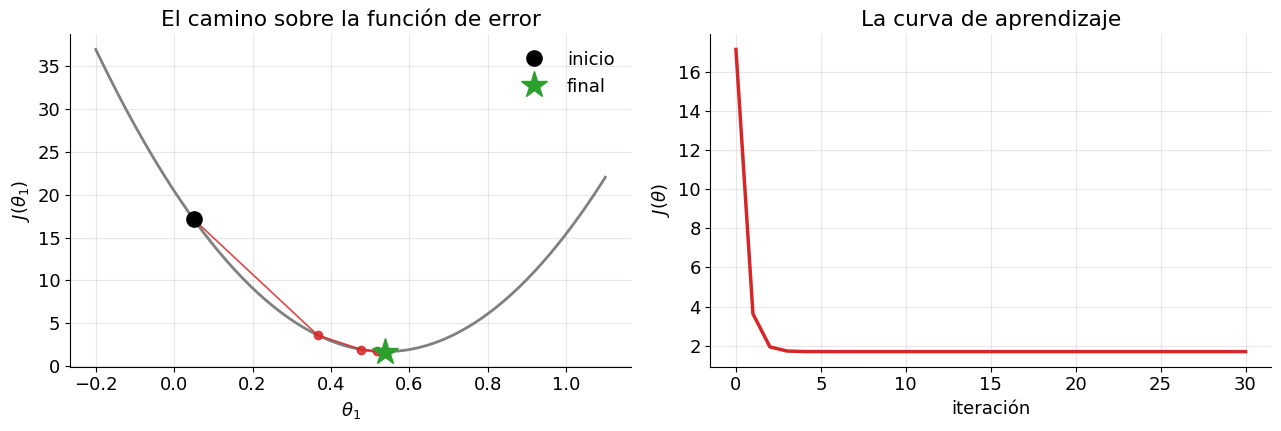

In [69]:
def plot_camino_1d(camino, costos_iter, rango=(-0.2, 1.1), ax=None, titulo=""):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ts = np.linspace(*rango, 200)
    ax.plot(ts, [J_mse(np.array([t]), X_horas, y_nota) for t in ts], c="gray", lw=2)
    ax.plot(camino[:, 0], costos_iter, "o-", c=C_MODELO, ms=6, lw=1.2, alpha=0.85)
    ax.plot(camino[0, 0], costos_iter[0], "o", c="black", ms=11, label="inicio")
    ax.plot(camino[-1, 0], costos_iter[-1], "*", c=C_APRUEBA, ms=20, label="final")
    ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$J(\theta_1)$")
    ax.set_title(titulo)
    ax.legend()
    return ax


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_camino_1d(camino, costos_iter, ax=axes[0], titulo="El camino sobre la función de error")
axes[1].plot(costos_iter, c=C_MODELO, lw=2.5)
axes[1].set_xlabel("iteración")
axes[1].set_ylabel(r"$J(\theta)$")
axes[1].set_title("La curva de aprendizaje")
plt.tight_layout()

**Los pasos son grandes cuando la pendiente es grande, y chiquitos cerca del mínimo.**

Eso sale gratis: la propia derivada se hace chica al acercarse al fondo.

# Learning rate

En la regla de actualización dijimos "movemos $\theta$ según lo que diga la derivada":

```python
theta = theta - alpha * gradiente(theta, X, y)
```

**¿Pero cuánto?** ¿0.1? ¿0.001? ¿100?

Eso es $\alpha$, el **learning rate**. Depende del problema, se **prueba y evalúa**. Las librerías traen defaults razonables, pero no es raro tener que cambiarlo.

Lo importante es saber **cómo darse cuenta** si está mal.

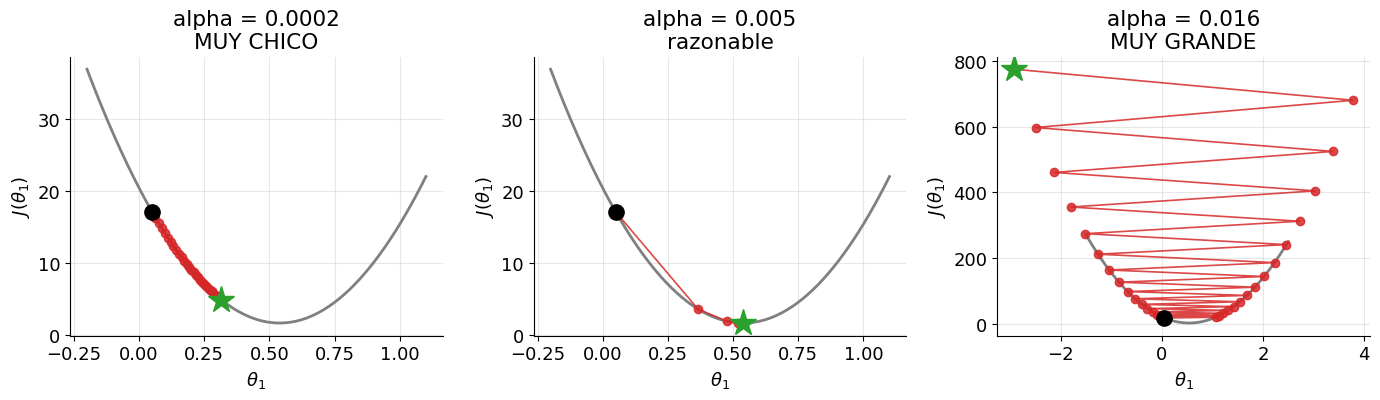

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for ax, (alpha, etiqueta, rango) in zip(axes, [
    (0.0002, "MUY CHICO", (-0.2, 1.1)),
    (0.0050, "razonable", (-0.2, 1.1)),
    (0.0160, "MUY GRANDE", (-1.5, 2.5)),
]):
    _, cam, cos = descenso_gradiente(X_horas, y_nota, J_mse, grad_mse,
                                     alpha=alpha, n_iters=30, theta_ini=[0.05])
    plot_camino_1d(cam, cos, rango=rango, ax=ax,
                   titulo="alpha = {}\n{}".format(alpha, etiqueta))
    ax.get_legend().remove()

plt.tight_layout()

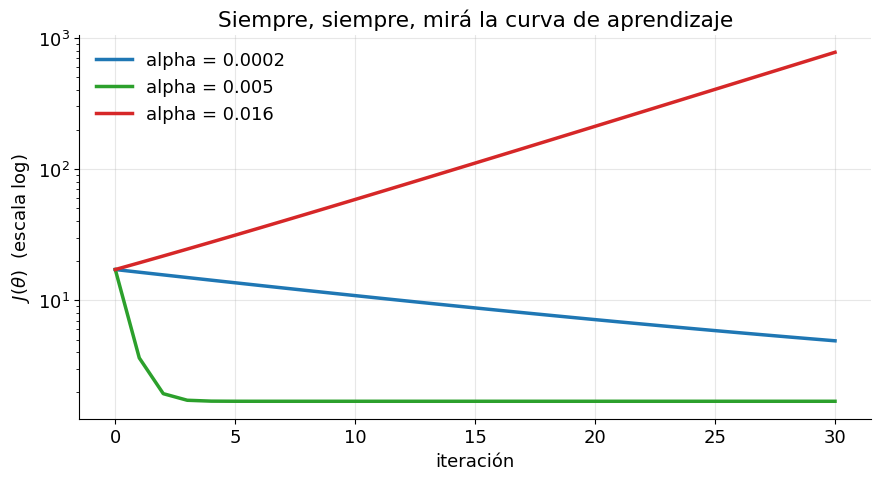

In [71]:
fig, ax = plt.subplots(figsize=(9, 5))

for alpha, color in [(0.0002, C_DATOS), (0.005, C_APRUEBA), (0.016, C_MODELO)]:
    _, _, cos = descenso_gradiente(X_horas, y_nota, J_mse, grad_mse,
                                   alpha=alpha, n_iters=30, theta_ini=[0.05])
    ax.plot(cos, lw=2.5, c=color, label="alpha = {}".format(alpha))

ax.set_yscale("log")
ax.set_xlabel("iteración")
ax.set_ylabel(r"$J(\theta)$  (escala log)")
ax.set_title("Siempre, siempre, mirá la curva de aprendizaje")
ax.legend()
plt.tight_layout()

# Cómo darse cuenta

**Learning rate muy chico** → va mejorando, pero **muy despacio**. Vas a esperar una eternidad.

**Learning rate muy grande** → se pasa del mínimo, rebota, y el error **empeora** (o explota a `nan`).

<br>

**La receta**: graficá $J$ por iteración. Si no baja, no es que "el modelo no sirve": revisá $\alpha$ primero.

# El valle alargado: escalar las entradas

Volvamos a los **dos** parámetros. `horas_estudio` va de 0 a 20 y `asistencia` de 40 a 100.

Un mismo paso $\alpha$ para todos los $\theta_j$ tiene que servir para variables de escalas distintas. Y no sirve.

In [72]:
# GD sobre los datos SIN escalar
theta_crudo, cam_crudo, cos_crudo = descenso_gradiente(
    Xb_horas, y_nota, J_mse, grad_mse,
    alpha=0.005, n_iters=250, theta_ini=[-3, 0.7],
)

# El óptimo exacto, para tener con qué comparar (ecuación normal / mínimos cuadrados)
optimo = np.linalg.lstsq(Xb_horas, y_nota, rcond=None)[0]

print("óptimo exacto        :", optimo.round(3))
print("GD tras 250 iters    :", theta_crudo.round(3))
print("¿llegó?              :", np.allclose(theta_crudo, optimo, atol=0.05))

óptimo exacto        : [3.023 0.305]
GD tras 250 iters    : [-1.498  0.655]
¿llegó?              : False


In [73]:
# Ahora estandarizamos: cada variable con media 0 y desvío 1
X_horas_std, mu_h, sd_h = estandarizar(X_horas)
Xb_horas_std = agregar_bias(X_horas_std)

theta_std, cam_std, cos_std = descenso_gradiente(
    Xb_horas_std, y_nota, J_mse, grad_mse,
    alpha=0.5, n_iters=250, theta_ini=[-3, 0.7],
)

optimo_std = np.linalg.lstsq(Xb_horas_std, y_nota, rcond=None)[0]
print("óptimo exacto        :", optimo_std.round(3))
print("GD tras 250 iters    :", theta_std.round(3))
print("¿llegó?              :", np.allclose(theta_std, optimo_std, atol=0.05))

óptimo exacto        : [6.069 1.665]
GD tras 250 iters    : [6.069 1.665]
¿llegó?              : True


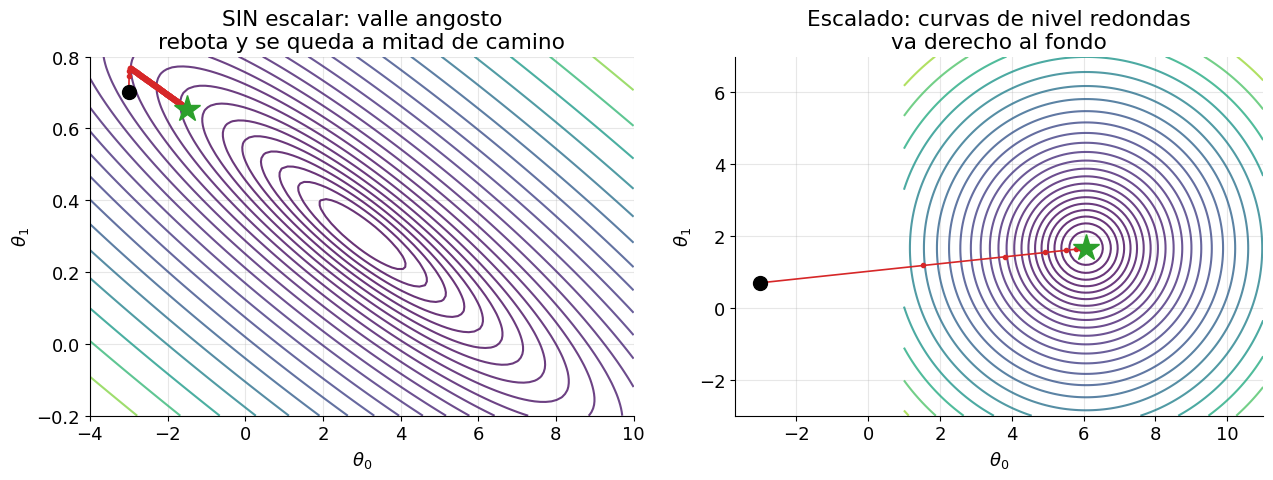

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (Xb_, cam_, rango0, rango1, redondo, titulo) in zip(axes, [
    (Xb_horas, cam_crudo, (-4, 10), (-0.2, 0.8), False,
     "SIN escalar: valle angosto\nrebota y se queda a mitad de camino"),
    (Xb_horas_std, cam_std, (1, 11), (-3, 7), True,
     "Escalado: curvas de nivel redondas\nva derecho al fondo"),
]):
    T0_, T1_, Z_ = malla_costo(rango0, rango1, Xb_, y_nota)
    ax.contour(T0_, T1_, Z_, levels=np.geomspace(Z_.min(), Z_.max(), 25),
               cmap="viridis", alpha=0.8)
    ax.plot(cam_[:, 0], cam_[:, 1], "o-", c=C_MODELO, ms=3, lw=1.2)
    ax.plot(cam_[0, 0], cam_[0, 1], "o", c="black", ms=10)
    ax.plot(cam_[-1, 0], cam_[-1, 1], "*", c=C_APRUEBA, ms=20)
    if redondo:
        ax.set_aspect("equal")     # sin esto, un círculo se ve como una elipse
    ax.set_xlabel(r"$\theta_0$")
    ax.set_ylabel(r"$\theta_1$")
    ax.set_title(titulo)

plt.tight_layout()

**Moraleja**: escalar las entradas no es cosmética, es lo que hace que el descenso funcione.

Guardá esta idea: en k-NN vamos a necesitar normalizar **por otra razón completamente distinta**.

# Variantes del descenso por el gradiente

Lo que implementamos se llama **batch** gradient descent: usa **todos** los ejemplos en cada paso.

* **SGD** (estocástico): un ejemplo por paso. Ruidoso pero rapidísimo.
* **Mini-batch**: de a 32, 64, 256 ejemplos. Lo que se usa en la práctica.
* **Momentum / Nesterov**: acumula inercia, atraviesa los valles angostos.
* **Adam**, **RMSProp**: adaptan un $\alpha$ **por parámetro**. El default de casi todo deep learning hoy.

Todas son la misma idea con un paso más astuto.

# El momento de la verdad

Nuestras ~10 líneas de numpy contra `scikit-learn`, con las **dos** variables.

In [75]:
X_std, mu, sd = estandarizar(X)
Xb_std = agregar_bias(X_std)

theta_mano, _, cos_mano = descenso_gradiente(
    Xb_std, y_nota, J_mse, grad_mse, alpha=0.3, n_iters=2000,
)

sk = LinearRegression().fit(X_std, y_nota)
theta_sklearn = np.r_[sk.intercept_, sk.coef_]

print(pd.DataFrame({
    "nuestro GD": theta_mano.round(4),
    "sklearn": theta_sklearn.round(4),
}, index=["theta_0", "theta_1 (horas)", "theta_2 (asistencia)"]))
print()
print("¿coinciden?", np.allclose(theta_mano, theta_sklearn, atol=1e-3))

                      nuestro GD  sklearn
theta_0                   6.0694   6.0694
theta_1 (horas)           1.6085   1.6085
theta_2 (asistencia)      0.7840   0.7840

¿coinciden? True


In [100]:
# Y si deshacemos la estandarización, ¿recuperamos la "verdad" que generó los datos?
coef_orig = theta_mano[1:] / sd
inter_orig = theta_mano[0] - (theta_mano[1:] * mu / sd).sum()

# error estándar de cada parámetro, para saber cuánto confiar en cada número
residuos = y_nota - h_lineal(theta_mano, Xb_std)
sigma2 = residuos @ residuos / (len(y_nota) - Xb_std.shape[1])
Xb_orig = agregar_bias(X)
errores_std = np.sqrt(sigma2 * np.linalg.inv(Xb_orig.T @ Xb_orig).diagonal())

print(pd.DataFrame({
    "aprendido": np.r_[inter_orig, coef_orig].round(3),
    "± error estándar": errores_std.round(3),
    "la verdad": np.array(THETA_REAL).round(3),
}, index=["theta_0", "horas_estudio", "asistencia"]))

               aprendido  ± error estándar  la verdad
theta_0            0.109             0.326       0.50
horas_estudio      0.295             0.014       0.28
asistencia         0.044             0.004       0.04


Las **pendientes** las clavamos: 0.28 y 0.040 reales contra 0.295 y 0.044 aprendidos.

El **intercepto** queda más lejos... y su error estándar explica por qué: $\theta_0$ es la nota de alguien que estudia **0 horas** y asiste al **0%** de las clases, y de eso **no tenemos un solo dato**. El modelo lo está extrapolando.

**Lección**: un parámetro puede estar mal estimado sin que el modelo prediga mal. Los parámetros que importan son los que están sostenidos por datos.

# Resumen descenso por el gradiente

Esta técnica sirve, **en teoría**, para aproximar cualquier función que se te ocurra. Solo hace falta:

1. Armar el **molde** de la función ($h_\theta$)
2. Elegir una **función de error** derivable
3. Hacer **descenso por el gradiente** sobre sus parámetros

<br>

**Esto es literalmente lo que hace una red neuronal.** Cambia el molde (mucho más grande), no el método.

Y es lo que vamos a hacer en los próximos 25 minutos con la regresión logística: **mismo algoritmo, otro molde**.

# Preguntas frecuentes

* **¿Y si no sé qué estructura tiene mi función?** → hasta que no lo sepas, no podés aplicar esto tal cual. Probás, evaluás.
* **¿Y si tengo muchos parámetros?** → derivadas parciales, todas a la vez, vectorizado.
* **¿No es muy lento?** → se vectoriza, se manda a GPU. Regresión lineal termina siendo rapidísima.
* **¿Hasta cuándo itero?** → depende del problema: cuando $J$ deja de bajar, o se te acaba el tiempo.
* **¿Y si mi función no es derivable?** → hay soluciones más complejas que no vemos hoy.

# Explicabilidad: el premio de la regresión lineal

Si las entradas están en la **misma escala** (por eso estandarizamos), los pesos nos dicen **cuánto impacta cada variable** en la salida.

* El valor **absoluto** → cuánto pesa esa variable.
* El **signo** → si la relación es directa o inversa.

Muy pocos modelos te explican el "por qué" de forma tan simple.

 horas_estudio : +1.608
    asistencia : +0.784


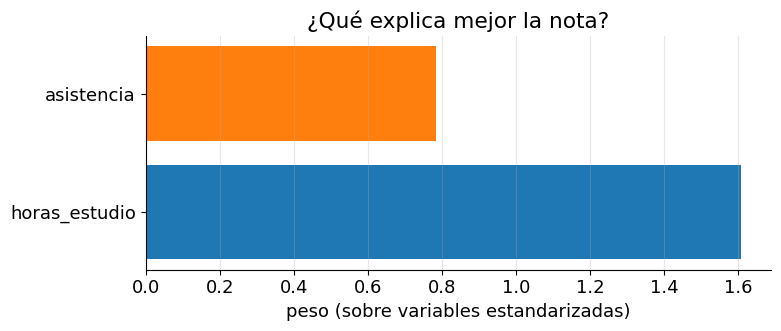

In [77]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(FEATURES, theta_mano[1:], color=[C_DATOS, C_EXTRA])
ax.set_xlabel("peso (sobre variables estandarizadas)")
ax.set_title("¿Qué explica mejor la nota?")
ax.grid(axis="y", alpha=0)
plt.tight_layout()

for nombre, peso in zip(FEATURES, theta_mano[1:]):
    print("{:>14} : {:+.3f}".format(nombre, peso))

# 4. Regresión logística

## Mismos alumnos, otra pregunta

*25 minutos*

# Ahora no queremos la nota, queremos saber si **aprueba**

$$ y \in \{0, 1\} $$

La primera tentación es obvia: ya tenemos regresión lineal andando... **¿la usamos y listo?**

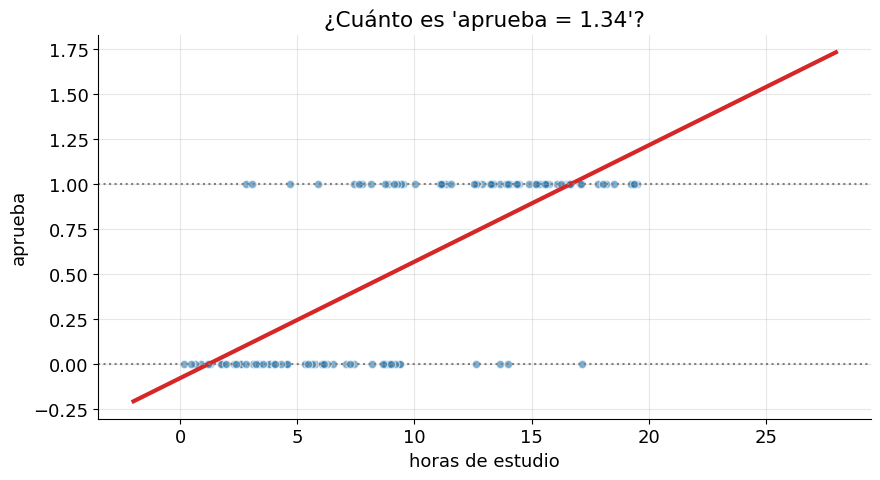

In [78]:
lineal_sobre_clases = LinearRegression().fit(X_horas, y_aprueba)

grilla = np.linspace(-2, 28, 200).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(alumnos.horas_estudio, alumnos.aprueba, c=C_DATOS, alpha=0.6, edgecolor="white")
ax.plot(grilla, lineal_sobre_clases.predict(grilla), c=C_MODELO, lw=3)
ax.axhline(1, ls=":", c="gray")
ax.axhline(0, ls=":", c="gray")
ax.set_xlabel("horas de estudio")
ax.set_ylabel("aprueba")
ax.set_title("¿Cuánto es 'aprueba = 1.34'?")
plt.tight_layout()

**Problema 1: las salidas no se limitan a los valores buscados.** Predice 1.34, o -0.2. No significan nada.

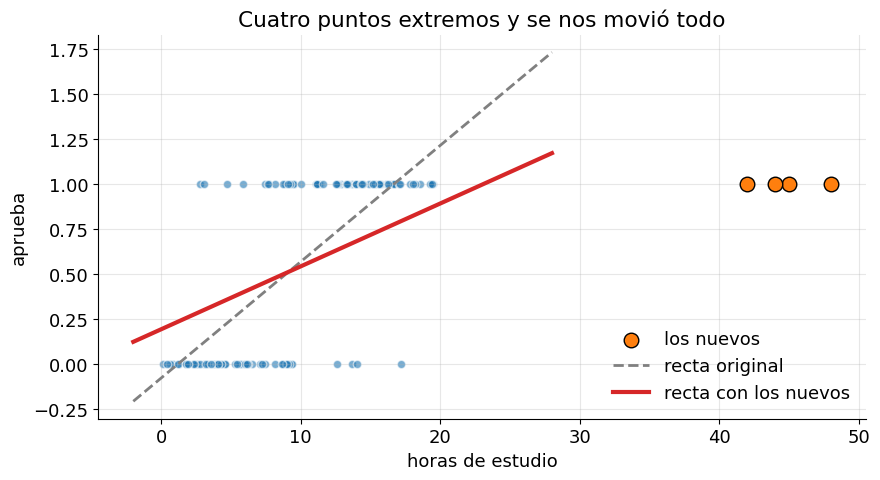

In [79]:
# Problema 2: agreguemos unos pocos alumnos obsesivos (45 h/semana, aprueban)
extremos = pd.DataFrame({"horas_estudio": [42.0, 45.0, 48.0, 44.0],
                         "asistencia": [100.0, 100.0, 98.0, 99.0],
                         "nota": [10.0, 10.0, 10.0, 10.0],
                         "aprueba": [1, 1, 1, 1]})
con_extremos = pd.concat([alumnos, extremos], ignore_index=True)

modelo_extremos = LinearRegression().fit(
    con_extremos[["horas_estudio"]].to_numpy(), con_extremos.aprueba.to_numpy())

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(con_extremos.horas_estudio, con_extremos.aprueba,
           c=C_DATOS, alpha=0.6, edgecolor="white")
ax.scatter(extremos.horas_estudio, extremos.aprueba, c=C_EXTRA, s=110,
           edgecolor="black", zorder=5, label="los nuevos")
ax.plot(grilla, lineal_sobre_clases.predict(grilla), c="gray", lw=2, ls="--",
        label="recta original")
ax.plot(grilla, modelo_extremos.predict(grilla), c=C_MODELO, lw=3,
        label="recta con los nuevos")
ax.set_xlabel("horas de estudio")
ax.set_ylabel("aprueba")
ax.legend(loc="lower right")
ax.set_title("Cuatro puntos extremos y se nos movió todo")
plt.tight_layout()

**Problema 2: unos pocos puntos extremos mueven considerablemente la recta**, y con ella el umbral de decisión.

Necesitamos otra cosa.

# Lo que queremos

$$ 0 \leq h_\theta(x) \leq 1 $$

### La función sigmoide (o logística)

$$ g(z) = \frac{1}{1 + e^{-z}} $$

Toma cualquier número real y lo **aplasta** al intervalo $(0, 1)$.

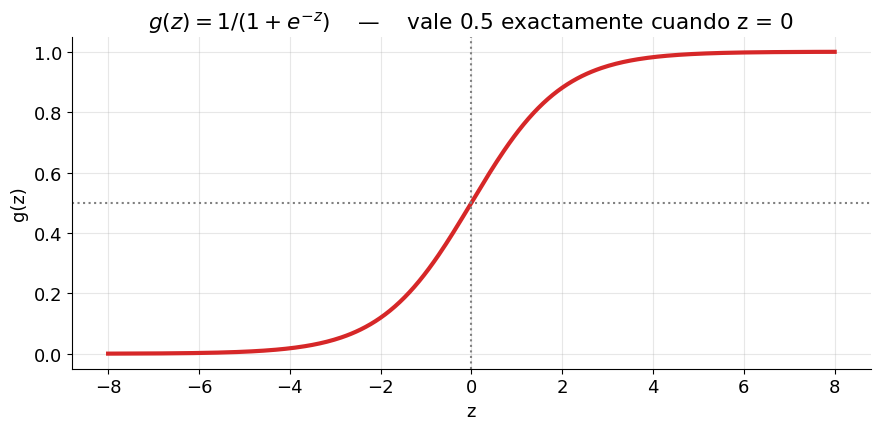

In [80]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-8, 8, 300)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(z, sigmoide(z), c=C_MODELO, lw=3)
ax.axhline(0.5, ls=":", c="gray")
ax.axvline(0, ls=":", c="gray")
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
ax.set_title(r"$g(z) = 1 / (1 + e^{-z})$    —    vale 0.5 exactamente cuando z = 0")
plt.tight_layout()

# El molde nuevo

**Antes:**

$$ h_\theta(x) = \theta^T x $$

**Ahora:**

$$ h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}} $$

Es la **misma recta de antes**, pasada por la sigmoide. Nada más.

# ¿Qué interpretación tiene esa salida numérica?

<br>

**Podemos leerla como la probabilidad de que la clase sea 1:**

$$ h_\theta(x) = P(y=1 \mid x; \theta) $$

$$ P(y=0 \mid x; \theta) = 1 - h_\theta(x) $$

Y para decidir, usamos un **threshold** (por defecto 0.5):

$$ \hat{y} = 1 \iff h_\theta(x) \geq 0.5 \iff \theta^T x \geq 0 $$
$$ \hat{y} = 0 \iff h_\theta(x) < 0.5 \iff \theta^T x < 0 $$

**Podemos elegir otro threshold** si nos conviene: ¿qué preferís, dar por aprobado a alguien que no sabe, o hacer recursar a alguien que sí?

La recta cruza el 0 en horas_estudio = 8.75
Ahí es donde el modelo cambia de opinión.


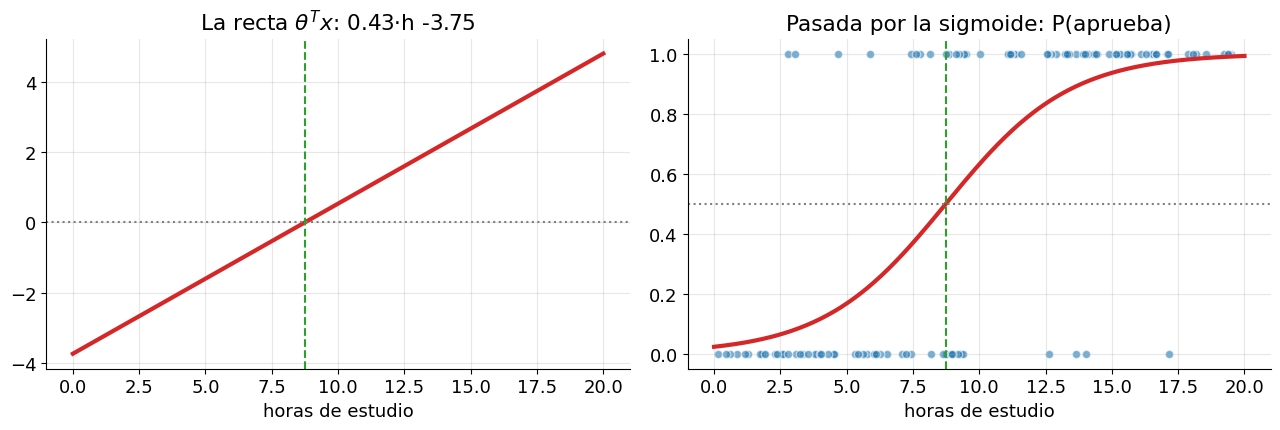

In [81]:
from sklearn.linear_model import LogisticRegression

log_uni = LogisticRegression().fit(X_horas, y_aprueba)

grilla_h = np.linspace(0, 20, 300)
recta = log_uni.coef_[0][0] * grilla_h + log_uni.intercept_[0]
probas = sigmoide(recta)
corte_x = -log_uni.intercept_[0] / log_uni.coef_[0][0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(grilla_h, recta, c=C_MODELO, lw=3)
axes[0].axhline(0, ls=":", c="gray")
axes[0].axvline(corte_x, ls="--", c=C_APRUEBA)
axes[0].set_title(r"La recta $\theta^T x$: {:.2f}·h {:+.2f}".format(
    log_uni.coef_[0][0], log_uni.intercept_[0]))
axes[0].set_xlabel("horas de estudio")

axes[1].scatter(alumnos.horas_estudio, alumnos.aprueba, c=C_DATOS,
                alpha=0.6, edgecolor="white")
axes[1].plot(grilla_h, probas, c=C_MODELO, lw=3)
axes[1].axhline(0.5, ls=":", c="gray")
axes[1].axvline(corte_x, ls="--", c=C_APRUEBA)
axes[1].set_title("Pasada por la sigmoide: P(aprueba)")
axes[1].set_xlabel("horas de estudio")

print("La recta cruza el 0 en horas_estudio = {:.2f}".format(corte_x))
print("Ahí es donde el modelo cambia de opinión.")
plt.tight_layout()

# Frontera de decisión

**Es el límite de los valores de entrada que hacen que el modelo cambie de clase predicha.**

$$ \theta^T x = 0 $$

<br>

**No confundir la frontera de decisión con la recta aprendida.** En el gráfico de la izquierda, la recta aprendida es roja; la frontera es la línea verde vertical.

# La frontera con dos variables

Nuestros datos se generaron con $nota = 0.5 + 0.28 \cdot h + 0.04 \cdot a + ruido$, y $aprueba$ si $nota \geq 6$.

Entonces la frontera "verdadera" es:

$$ 0.5 + 0.28 h + 0.04 a = 6 \quad \Longrightarrow \quad 0.28 h + 0.04 a = 5.5 $$

Que es exactamente lo que la regresión logística puede representar, con $\theta = (-5.5,\ 0.28,\ 0.04)$:

$$ g(-5.5 + 0.28h + 0.04a) \geq 0.5 \iff -5.5 + 0.28h + 0.04a \geq 0 \iff 0.28h + 0.04a \geq 5.5 $$

**Con dos variables la frontera es una recta. Con tres, un plano. Con n, un hiperplano.**

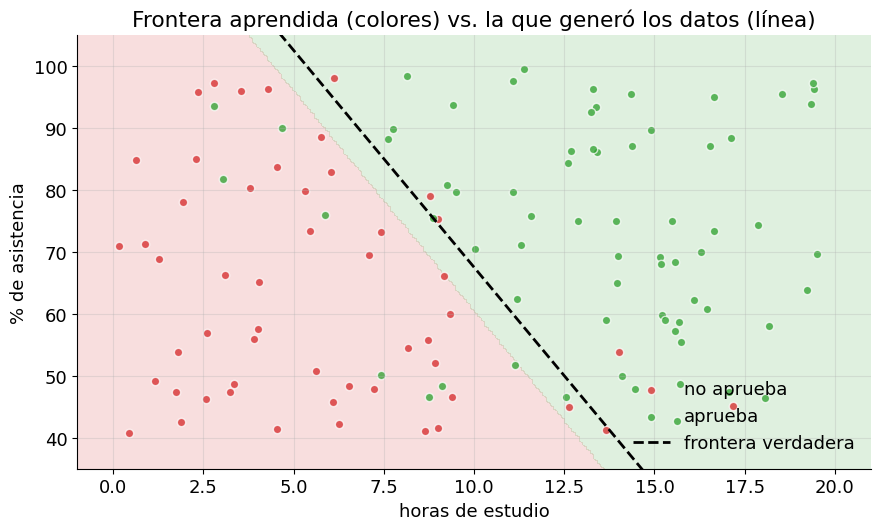

In [82]:
log_2d = LogisticRegression().fit(X, y_aprueba)

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_frontera(log_2d.predict, ax)
plot_clases(ax=ax)

# la frontera "verdadera": 0.28h + 0.04a = 5.5
hh = np.linspace(-1, 21, 50)
ax.plot(hh, (5.5 - 0.28 * hh) / 0.04, c="black", ls="--", lw=2,
        label="frontera verdadera")
ax.legend(loc="lower right")
ax.set_title("Frontera aprendida (colores) vs. la que generó los datos (línea)")
plt.tight_layout()

# ¿Y cómo aprendemos $\theta$?

Ya sabemos el método: **función de error + descenso por el gradiente**.

Solo falta elegir la función de error. ¿Reusamos el error cuadrático?

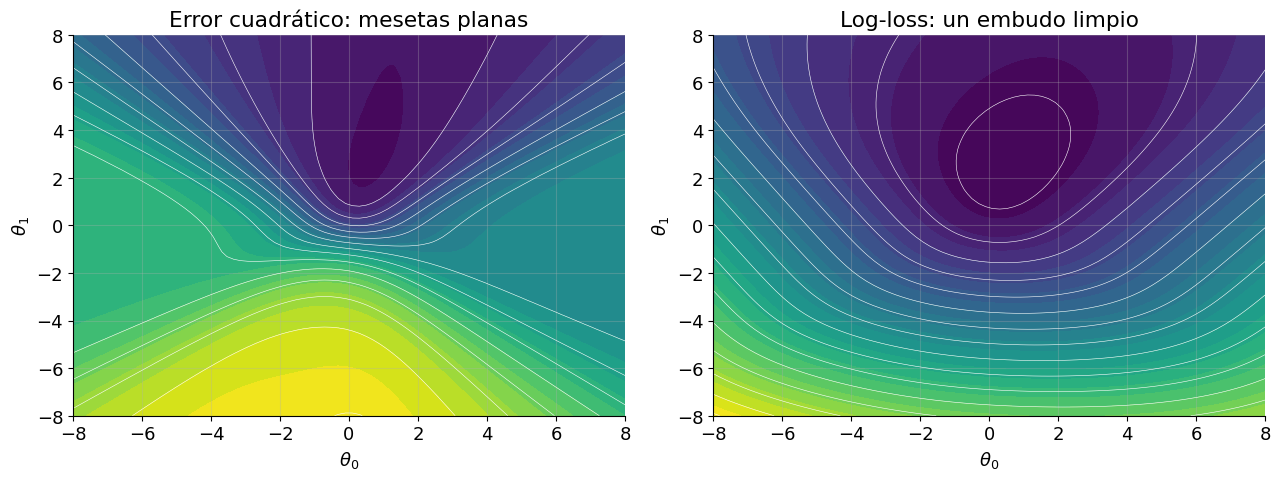

In [83]:
def h_logistica(theta, X_):
    return sigmoide(X_ @ theta)


def J_mse_logistica(theta, X_, y_):
    '''Error cuadrático, pero con la hipótesis logística. Mala idea, veamos por qué.'''
    return np.mean((h_logistica(theta, X_) - y_) ** 2) / 2


def J_logloss(theta, X_, y_):
    p = np.clip(h_logistica(theta, X_), 1e-12, 1 - 1e-12)
    return -np.mean(y_ * np.log(p) + (1 - y_) * np.log(1 - p))


Xb_horas_std_cls = Xb_horas_std   # mismas features, otro target
T0c, T1c, Z_mse = malla_costo((-8, 8), (-8, 8), Xb_horas_std_cls, y_aprueba,
                              costo=J_mse_logistica, n=80)
_, _, Z_log = malla_costo((-8, 8), (-8, 8), Xb_horas_std_cls, y_aprueba,
                          costo=J_logloss, n=80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z_, t in zip(axes, [Z_mse, Z_log],
                     ["Error cuadrático: mesetas planas", "Log-loss: un embudo limpio"]):
    cs = ax.contourf(T0c, T1c, Z_, levels=25, cmap="viridis")
    ax.contour(T0c, T1c, Z_, levels=15, colors="white", linewidths=0.4)
    ax.set_xlabel(r"$\theta_0$")
    ax.set_ylabel(r"$\theta_1$")
    ax.set_title(t)
plt.tight_layout()

**El error cuadrático es una función poco conveniente acá**: la sigmoide se satura, y aparecen enormes **regiones planas** donde el gradiente es casi cero y el descenso no sabe para dónde ir. Además, en general **no es convexa**: puede tener mínimos locales.

Necesitamos una función de error hecha a medida.

# La función de costo de la regresión logística

$$ C(h_\theta(x), y) = \begin{cases} -\log(h_\theta(x)) & \text{si } y = 1 \\ -\log(1-h_\theta(x)) & \text{si } y = 0 \end{cases} $$

La idea: **si estás seguro y te equivocás, el castigo es infinito.**

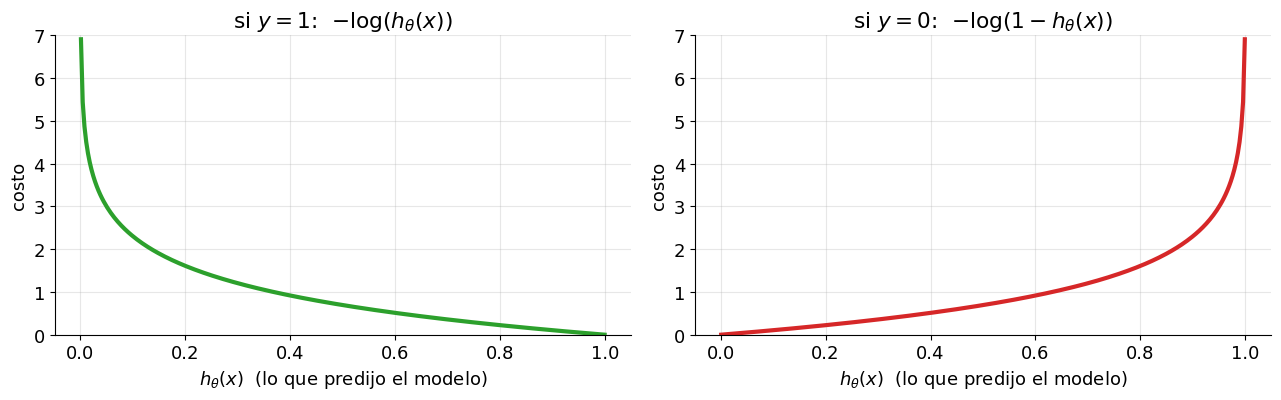

In [84]:
p = np.linspace(0.001, 0.999, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(p, -np.log(p), c=C_APRUEBA, lw=3)
axes[0].set_title(r"si $y = 1$:  $-\log(h_\theta(x))$")

axes[1].plot(p, -np.log(1 - p), c=C_NO, lw=3)
axes[1].set_title(r"si $y = 0$:  $-\log(1 - h_\theta(x))$")

for ax in axes:
    ax.set_xlabel(r"$h_\theta(x)$  (lo que predijo el modelo)")
    ax.set_ylabel("costo")
    ax.set_ylim(0, 7)
plt.tight_layout()

# ¿Podemos unificar esos dos casos?

$$ C(h_\theta(x), y) = \begin{cases} -\log(h_\theta(x)) & y = 1 \\ -\log(1-h_\theta(x)) & y = 0 \end{cases} $$

### Truco: $y$ siempre vale 0 o 1, entonces lo usamos como interruptor...

$$ C(h_\theta(x), y) = -y\log(h_\theta(x)) - (1-y)\log(1-h_\theta(x)) $$

Si $y=1$ el segundo término se apaga; si $y=0$ se apaga el primero. Elegante.

# Finalmente

$$ J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[ y^i \log h_\theta(x^i) + (1-y^i)\log\left(1-h_\theta(x^i)\right) \right] $$

Se la conoce como **log-loss**, **cross-entropy** o **binary cross-entropy**.

Y es **convexa**: un solo mínimo, sin sorpresas.

# El regalo: el gradiente es EL MISMO

Si derivás $J$ log-loss con $h_\theta = g(\theta^Tx)$ (dos carillas de regla de la cadena, la sigmoide tiene una derivada muy amable), sale:

$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^i) - y^i\right)x_j^i $$

<br>

### Idéntico, letra por letra, al de la regresión lineal.

Lo único que cambia es **qué es $h_\theta$**. O sea: podemos reusar `descenso_gradiente` **sin tocarlo**.

### Regresión lineal vs. logística: todo lo que cambia

#### Regresión lineal
$$ h_\theta(x) = \theta^Tx \qquad C = \frac{1}{2}(h_\theta(x)-y)^2 $$

#### Regresión logística
$$ h_\theta(x) = \frac{1}{1+e^{-\theta^Tx}} \qquad C = -y\log(h_\theta(x)) - (1-y)\log(1-h_\theta(x)) $$

#### Descenso por el gradiente
$$ \theta_j := \theta_j - \frac{\alpha}{m}\sum_i (h_\theta(x^i) - y^i)x_j^i \qquad \text{(el mismo para los dos)} $$

theta aprendido a mano: [0.6509 2.9408 1.3656]


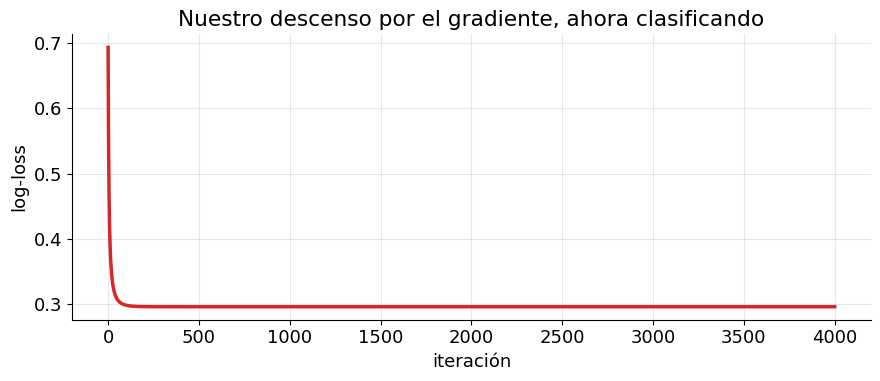

In [85]:
def grad_logloss(theta, X_, y_):
    '''Mirá la línea de abajo y comparala con grad_mse. Solo cambió la h.'''
    return X_.T @ (h_logistica(theta, X_) - y_) / len(y_)


# La MISMA función de la parte 3, sin modificar una coma
theta_log, _, cos_log = descenso_gradiente(
    Xb_std, y_aprueba, J_logloss, grad_logloss, alpha=0.5, n_iters=4000,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cos_log, c=C_MODELO, lw=2.5)
ax.set_xlabel("iteración")
ax.set_ylabel("log-loss")
ax.set_title("Nuestro descenso por el gradiente, ahora clasificando")
plt.tight_layout()

print("theta aprendido a mano:", theta_log.round(4))

In [86]:
# Contra sklearn. Ojo: por defecto sklearn REGULARIZA, así que lo apagamos
# para comparar contra la log-loss pura que optimizamos nosotros.
# (cómo se apaga cambió en sklearn 1.8)
import sklearn
import warnings

version_sk = tuple(int(p) for p in sklearn.__version__.split(".")[:2])
sin_regularizar = {"C": np.inf} if version_sk >= (1, 8) else {"penalty": None}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sk_log = LogisticRegression(max_iter=5000, **sin_regularizar).fit(X_std, y_aprueba)

theta_sk_log = np.r_[sk_log.intercept_, sk_log.coef_[0]]

print(pd.DataFrame({
    "nuestro GD": theta_log.round(3),
    "sklearn": theta_sk_log.round(3),
}, index=["theta_0", "theta_1 (horas)", "theta_2 (asistencia)"]))
print()
print("¿coinciden (tol. 2%)?", np.allclose(theta_log, theta_sk_log, rtol=0.02, atol=0.02))

                      nuestro GD  sklearn
theta_0                    0.651    0.651
theta_1 (horas)            2.941    2.941
theta_2 (asistencia)       1.366    1.365

¿coinciden (tol. 2%)? True


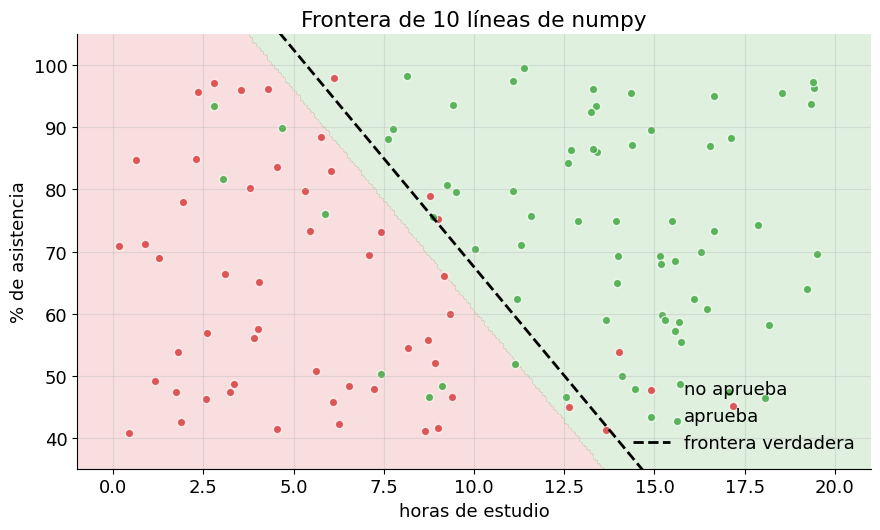

In [87]:
# Y la frontera que aprendió NUESTRA implementación
def predecir_a_mano(X_nuevo):
    X_nuevo_std, _, _ = estandarizar(np.asarray(X_nuevo, float), mu, sd)
    return (h_logistica(theta_log, agregar_bias(X_nuevo_std)) >= 0.5).astype(int)


fig, ax = plt.subplots(figsize=(9, 5.5))
plot_frontera(predecir_a_mano, ax)
plot_clases(ax=ax)
hh = np.linspace(-1, 21, 50)
ax.plot(hh, (5.5 - 0.28 * hh) / 0.04, c="black", ls="--", lw=2,
        label="frontera verdadera")
ax.legend(loc="lower right")
ax.set_title("Frontera de 10 líneas de numpy")
plt.tight_layout()

# 5. k vecinos más cercanos (k-NN)

## El modelo que no tiene parámetros

*20 minutos*

# Prediciendo con la intuición

Viene un alumno nuevo: estudia 12 horas por semana y asistió al 62% de las clases.

**¿Aprueba?**

<br>

Hasta ahora la respuesta era: "evaluá $h_\theta$". Ahora vamos a probar otra cosa, mucho más humana:

### *"Busquemos a los alumnos más parecidos a él, y veamos qué les pasó."*

predicción por mayoría: aprueba


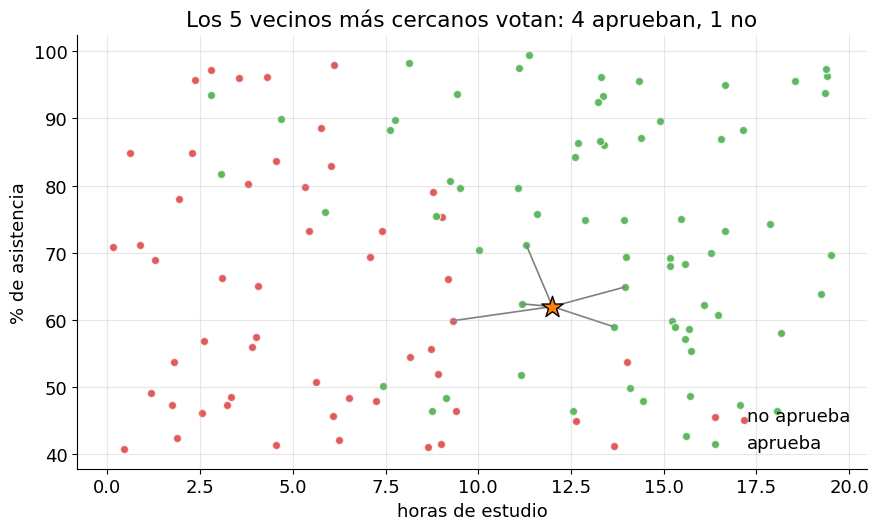

In [88]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error

nuevo = np.array([12.0, 62.0])
K = 5

# distancias medidas sobre las variables estandarizadas (ya vamos a ver por qué)
distancias = np.linalg.norm((X - nuevo) / sd, axis=1)
vecinos = np.argsort(distancias)[:K]

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_clases(ax=ax)
for i in vecinos:
    ax.plot([nuevo[0], X[i, 0]], [nuevo[1], X[i, 1]], c="gray", lw=1.2, zorder=1)
ax.scatter(*nuevo, c=C_EXTRA, s=260, marker="*", edgecolor="black", zorder=5)
ax.set_title("Los {} vecinos más cercanos votan: {} aprueban, {} no".format(
    K, y_aprueba[vecinos].sum(), K - y_aprueba[vecinos].sum()))
plt.tight_layout()

print("predicción por mayoría:", "aprueba" if y_aprueba[vecinos].mean() >= 0.5 else "no aprueba")

# Vecinos más cercanos (k-NN)

- Se lo conoce también como **aprendizaje basado en casos** o **lazy learning**: no hay ningún cálculo hasta el momento de predecir.
- **El modelo no existe explícitamente** (es *no paramétrico*): no hay $\theta$, no hay función de error, no hay descenso por el gradiente. **El modelo son los datos.**
- El único parámetro a elegir es **k**: cuántos vecinos consultamos.
- Es muy **dependiente e inestable** en k.

<br>

**Acordate del Bloque 1**: dijimos que el conocimiento quedaba en los parámetros y que podíamos tirar los datos. Acá pasa exactamente lo contrario.

# Formas de medir la distancia

### Distancia de Minkowski

$$ L^p(x_j, x_q) = \left(\sum_i |x_{j,i} - x_{q,i}|^p\right)^{\frac{1}{p}} $$

- $p = 2$ → distancia **euclídea** (la de siempre, en línea recta)
- $p = 1$ → distancia **Manhattan** (por las calles de la cuadrícula)

No son las únicas: coseno, Hamming, Mahalanobis, Jaccard...

<https://machinelearningmastery.com/distance-measures-for-machine-learning/>

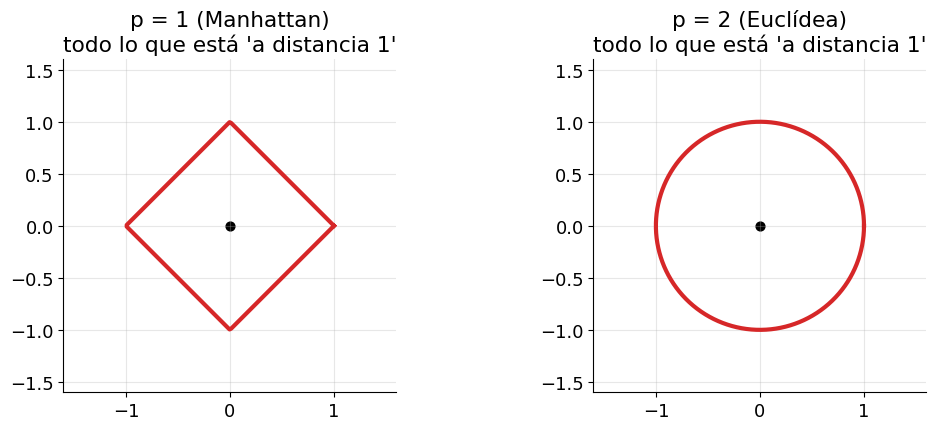

In [89]:
angulos = np.linspace(0, 2 * np.pi, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, p, titulo in [(axes[0], 1, "p = 1 (Manhattan)"), (axes[1], 2, "p = 2 (Euclídea)")]:
    # "círculo unitario" de la norma p: todos los puntos a distancia 1 del centro
    c, s = np.cos(angulos), np.sin(angulos)
    r = (np.abs(c) ** p + np.abs(s) ** p) ** (-1 / p)
    ax.plot(r * c, r * s, c=C_MODELO, lw=3)
    ax.scatter(0, 0, c="black", s=40)
    ax.set_aspect("equal")
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    ax.set_title(titulo + "\ntodo lo que está 'a distancia 1'")

plt.tight_layout()

# ⚠️ Hay que normalizar los datos

La distancia suma las diferencias de **todas** las variables.

`horas_estudio` se mueve entre 0 y 20. `asistencia` entre 40 y 100.

**Una diferencia de 10 puntos de asistencia pesa lo mismo que 10 horas de estudio por semana.** Que es un disparate.

<br>

Y ojo: es un problema **distinto** al del Bloque 3. Ahí escalar aceleraba la convergencia. Acá escalar **cambia qué es "parecido"**, o sea cambia el modelo.

In [90]:
def accuracy_media(hacer_modelo, X_, y_, repeticiones=20):
    '''Promedia accuracy de test sobre varios splits, para no mirar ruido.'''
    scores = []
    for r in range(repeticiones):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_, y_, test_size=0.3, random_state=r, stratify=y_)
        modelo = hacer_modelo().fit(X_tr, y_tr)
        scores.append(accuracy_score(y_te, modelo.predict(X_te)))
    return np.mean(scores)


X_asist_inflada = X * np.array([1, 10])    # como si midiéramos asistencia en 'por mil'

resultados = pd.DataFrame({
    "accuracy de test": [
        accuracy_media(lambda: KNeighborsClassifier(5), X, y_aprueba),
        accuracy_media(lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
                       X, y_aprueba),
        accuracy_media(lambda: KNeighborsClassifier(5), X_asist_inflada, y_aprueba),
        accuracy_media(lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
                       X_asist_inflada, y_aprueba),
    ]}, index=["crudo", "estandarizado",
               "crudo, asistencia x10", "estandarizado, asistencia x10"])
resultados.round(4)

,accuracy de test
crudo,0.8167
estandarizado,0.8208
"crudo, asistencia x10",0.6472
"estandarizado, asistencia x10",0.8208


Las dos filas **estandarizadas** dan **exactamente** lo mismo: al modelo no le importa en qué unidad mediste.

Las dos **crudas** dan distinto. En las unidades originales casi no se nota — pero eso es **suerte**, no diseño: las escalas resultaron parecidas. Al medir la asistencia en tanto por mil, la misma línea de código se derrumba.

### Sin normalizar, la elección de unidades decide el modelo. Y las unidades son una decisión arbitraria de quien armó el CSV.

# El efecto de k

$$ k = 1 \rightarrow \textbf{overfitting} $$

$$ k = m \rightarrow \textbf{underfitting} \quad (\texttt{return np.bincount(y).argmax()}) $$

Con $k=1$ le creemos a cada punto individual, incluido el ruido. Con $k=m$ predecimos siempre la clase mayoritaria y nos olvidamos de las entradas.

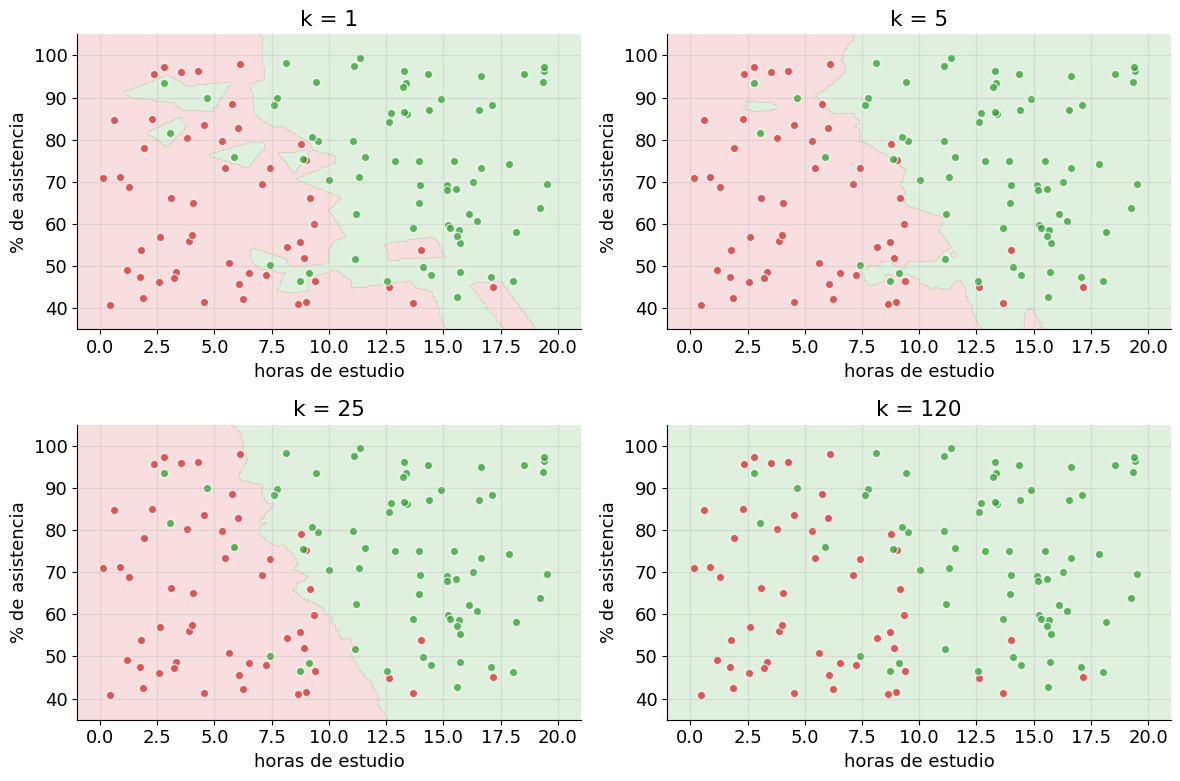

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, k in zip(axes.ravel(), [1, 5, 25, len(X)]):
    modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X, y_aprueba)
    plot_frontera(modelo.predict, ax)
    plot_clases(ax=ax)
    ax.get_legend().remove()
    ax.set_title("k = {}".format(k))

plt.tight_layout()

**k=1**: islas, penínsulas, cada punto ruidoso se defiende. &nbsp; **k=25**: una frontera suave, casi la recta que buscábamos. &nbsp; **k=m**: todo de un color.

k controla el **sesgo/varianza**, igual que la complejidad en cualquier otro modelo.

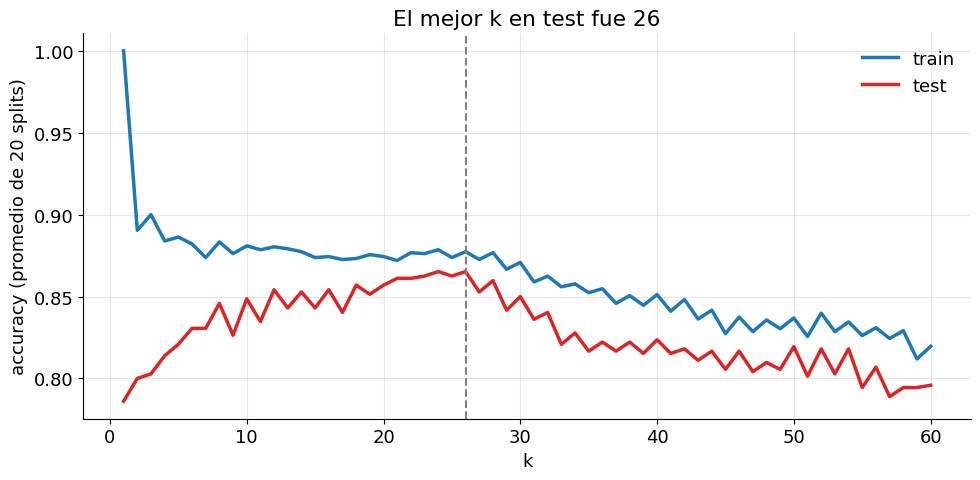

In [92]:
k_max = 61
k_valores = range(1, k_max)
train_scores, test_scores = [], []

for k in k_valores:
    tr, te = [], []
    for r in range(20):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y_aprueba, test_size=0.3, random_state=r, stratify=y_aprueba)
        modelo = make_pipeline(StandardScaler(),
                               KNeighborsClassifier(n_neighbors=k)).fit(X_tr, y_tr)
        tr.append(accuracy_score(y_tr, modelo.predict(X_tr)))
        te.append(accuracy_score(y_te, modelo.predict(X_te)))
    train_scores.append(np.mean(tr))
    test_scores.append(np.mean(te))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_valores), train_scores, lw=2.5, c=C_DATOS, label="train")
ax.plot(list(k_valores), test_scores, lw=2.5, c=C_MODELO, label="test")
mejor_k = list(k_valores)[int(np.argmax(test_scores))]
ax.axvline(mejor_k, ls="--", c="gray")
ax.set_xlabel("k")
ax.set_ylabel("accuracy (promedio de 20 splits)")
ax.set_title("El mejor k en test fue {}".format(mejor_k))
ax.legend()
plt.tight_layout()

En **k=1** el train da 100% (cada punto es su propio vecino) y el test es malo: **overfitting de manual**.

Después el test mejora, hace una meseta, y con k muy grande vuelve a caer: **underfitting**.

**k se elige con validación, nunca mirando el train.**

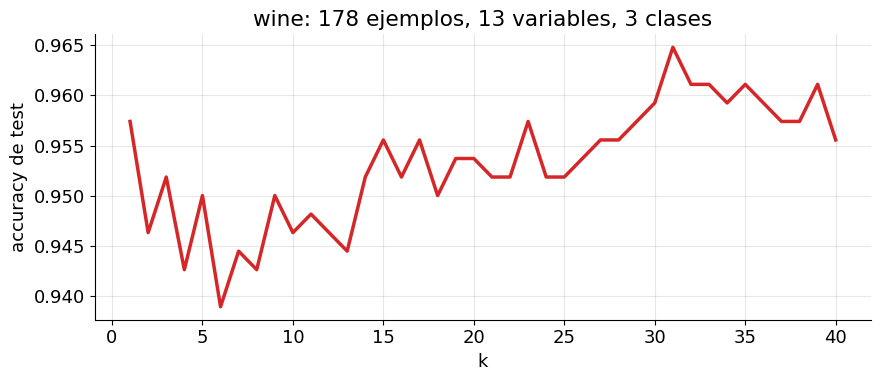

In [93]:
# Un dataset real, con 13 dimensiones en lugar de 2
from sklearn import datasets

wines = datasets.load_wine()
Xw, yw = wines.data, wines.target

curva_w = []
for k in range(1, 41):
    def armar(k=k):
        return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    curva_w.append(accuracy_media(armar, Xw, yw, repeticiones=10))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 41), curva_w, lw=2.5, c=C_MODELO)
ax.set_xlabel("k")
ax.set_ylabel("accuracy de test")
ax.set_title("wine: {} ejemplos, {} variables, {} clases".format(
    Xw.shape[0], Xw.shape[1], len(set(yw))))
plt.tight_layout()

# La letra chica de k-NN

* **Entrenar es gratis** (guardar los datos). **Predecir es caro**: hay que calcular la distancia contra todo el dataset, cada vez.
* **Deployar el modelo implica mover los datos** a producción. Con todo lo que eso significa: tamaño, privacidad, versionado.
* **No hace selección de variables**: una columna irrelevante pesa lo mismo que la más importante.
* **Maldición de la dimensionalidad**: en muchas dimensiones, todos los puntos quedan más o menos igual de lejos, y "vecino" pierde sentido.
* Funciona bien con **muchos datos y pocas dimensiones**.
* **No te explica nada** más allá de "estos 5 se parecen".

*(Más detalle en pág. 226 de "Data Science from Scratch", Joel Grus.)*

# Algunas variantes

### k-NN con rechazos
Exige garantías para predecir (por ejemplo, 75% de mayoría). Si no las tiene, deja el caso **sin clasificar** hasta tener más datos o usar otro método.

### k-NN de distancias medias
Calcula la distancia media a **cada clase** y asigna la de distancia menor.

### k-NN sobre representaciones intermedias
Usa una estructura (KD-tree, ball-tree, índices ANN tipo HNSW) para agrupar casos parecidos de antemano y hacer muchas menos cuentas.

<br>

*Los índices vectoriales que se usan hoy en búsqueda semántica y RAG son, en el fondo, k-NN a gran escala.*

In [94]:
# Y también sirve para REGRESIÓN: en vez de votar, promediamos las notas
X_tr, X_te, y_tr, y_te = train_test_split(X, y_nota, test_size=0.3, random_state=SEED)

knn_reg = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=7)).fit(X_tr, y_tr)
lin_reg = LinearRegression().fit(X_tr, y_tr)

print("MAE k-NN (k=7)      : {:.3f}".format(mean_absolute_error(y_te, knn_reg.predict(X_te))))
print("MAE regresión lineal: {:.3f}".format(mean_absolute_error(y_te, lin_reg.predict(X_te))))
print()
print("Los datos son lineales por construcción: acá la regresión lineal debería ganar.")
print("Con una relación curva, la historia sería otra.")

MAE k-NN (k=7)      : 0.909
MAE regresión lineal: 0.789

Los datos son lineales por construcción: acá la regresión lineal debería ganar.
Con una relación curva, la historia sería otra.


# 6. Cierre

*20 minutos*

# Los tres modelos, lado a lado

| | Regresión lineal | Regresión logística | k-NN |
|---|---|---|---|
| **Tarea** | regresión | clasificación | las dos |
| **Hipótesis** $h_\theta$ | $\theta^Tx$ | $g(\theta^Tx)$ | voto / promedio de los k vecinos |
| **Parámetros** | $\theta$ (n+1 números) | $\theta$ (n+1 números) | **ninguno** |
| **Hiperparámetros** | $\alpha$, iteraciones | $\alpha$, iteraciones, threshold | **k**, distancia |
| **Función de error** | MSE | log-loss | no tiene |
| **Cómo entrena** | descenso por el gradiente | descenso por el gradiente | no entrena |
| **Costo de entrenar** | bajo | bajo | **cero** |
| **Costo de predecir** | **mínimo** | mínimo | **alto** (todo el dataset) |
| **Qué se deploya** | n+1 números | n+1 números | **todos los datos** |
| **Escalar entradas** | conviene (converge mejor) | conviene | **obligatorio** |
| **Explicabilidad** | **excelente** (los pesos) | buena (pesos + probabilidad) | pobre |
| **Supone que...** | la relación es lineal | la frontera es lineal | los parecidos terminan igual |

# La idea que se repite

**Lineal y logística son el mismo algoritmo.** Cambia el molde y cambia la función de error; el motor es idéntico:

$$ \theta := \theta - \alpha \nabla J(\theta) $$

Ese motor es el que mueve **casi todo** el machine learning moderno, redes neuronales incluidas. Si entendés esto, entendiste la parte difícil.

<br>

**k-NN está en la otra vereda.** No hay molde, no hay error, no hay gradiente. Sirve para recordar que "aprender" no es necesariamente "ajustar parámetros", y que a veces el modelo más tonto alcanza.

<br>

**Y algo que vale para los tres**: mirá tus datos, escalá tus variables, y no le creas al accuracy de train.

# Desafío integrador

Con el **mismo** `alumnos` de toda la clase, y un split de train/test:

1. Entrená los **tres** modelos y compará sus métricas.
2. Predecí el caso de un alumno nuevo con cada uno, e interpretá las tres respuestas.
3. Contestá las tres preguntas conceptuales del final.

<br>

*Las celdas siguientes tienen el andamiaje. A completar.*

In [95]:
# --- 1. Entrenar y comparar -----------------------------------------
X_tr, X_te, y_tr_nota, y_te_nota = train_test_split(
    X, y_nota, test_size=0.3, random_state=SEED)
_, _, y_tr_cls, y_te_cls = train_test_split(
    X, y_aprueba, test_size=0.3, random_state=SEED)

# TODO a) regresión lineal para predecir la nota  -> reportar MAE en test
# TODO b) regresión logística para predecir aprueba -> reportar accuracy en test
# TODO c) k-NN (con StandardScaler!) para predecir aprueba -> reportar accuracy en test
#         ¿qué k elegís, y cómo lo justificás?

In [96]:
# --- SOLUCIÓN 1 (no se proyecta) ------------------------------------
lin = LinearRegression().fit(X_tr, y_tr_nota)
log = LogisticRegression(max_iter=1000).fit(X_tr, y_tr_cls)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)).fit(X_tr, y_tr_cls)

print("lineal   -> MAE en nota   : {:.3f}".format(
    mean_absolute_error(y_te_nota, lin.predict(X_te))))
print("logística-> accuracy      : {:.3f}".format(
    accuracy_score(y_te_cls, log.predict(X_te))))
print("k-NN k=15-> accuracy      : {:.3f}".format(
    accuracy_score(y_te_cls, knn.predict(X_te))))
print()
print("k se justifica con la curva de validación del bloque 5, no probando en test.")

lineal   -> MAE en nota   : 0.789
logística-> accuracy      : 0.806
k-NN k=15-> accuracy      : 0.778

k se justifica con la curva de validación del bloque 5, no probando en test.


In [97]:
# --- 2. Un alumno nuevo ---------------------------------------------
alumno_nuevo = np.array([[9.0, 55.0]])     # 9 h/semana, 55% de asistencia

# TODO a) ¿qué nota le predice la regresión lineal?
# TODO b) ¿con qué probabilidad aprueba, según la logística?  (predict_proba)
# TODO c) ¿qué dice k-NN? ¿quiénes son sus vecinos?
# TODO d) las tres respuestas, ¿son coherentes entre sí? ¿cuál le mostrarías al alumno?

In [98]:
# --- SOLUCIÓN 2 (no se proyecta) ------------------------------------
print("nota predicha        : {:.2f}".format(lin.predict(alumno_nuevo)[0]))
print("P(aprueba) logística : {:.3f}".format(log.predict_proba(alumno_nuevo)[0, 1]))
print("k-NN dice            : {}".format(
    "aprueba" if knn.predict(alumno_nuevo)[0] == 1 else "no aprueba"))

d = np.linalg.norm((X_tr - alumno_nuevo) / sd, axis=1)
print("\nsus 5 vecinos más cercanos (horas, asistencia, aprueba):")
for i in np.argsort(d)[:5]:
    print("   {:.1f} h   {:.0f}%   ->  {}".format(*X_tr[i], y_tr_cls[i]))

nota predicha        : 4.97
P(aprueba) logística : 0.111
k-NN dice            : no aprueba

sus 5 vecinos más cercanos (horas, asistencia, aprueba):
   8.7 h   56%   ->  0
   8.2 h   54%   ->  0
   8.9 h   52%   ->  0
   9.4 h   46%   ->  0
   11.2 h   62%   ->  1


# 3. Tres preguntas para pensar

**a)** Si mañana medimos `asistencia` en *tanto por mil* (0 a 1000) en lugar de porcentaje, **¿qué modelo da resultados distintos y cuál no se entera?** ¿Por qué?

**b)** El alumno te pide que le expliques **por qué** el modelo dice que va a desaprobar. **¿Con qué modelo podés contestarle?** ¿Qué le decís exactamente?

**c)** Tenés que servir 50.000 predicciones por segundo. **¿Qué modelo te cuesta más en producción y por qué?**

# Respuestas (no se proyectan)

**a)** k-NN cambia: la distancia depende de las unidades, así que cambia quiénes son "los vecinos". Lineal y logística **no cambian sus predicciones**: el peso de esa variable simplemente se divide por 10 y compensa. (Sí cambia la velocidad de convergencia del descenso, y la comparabilidad de los pesos entre sí.)

**b)** Con la lineal (o la logística): "cada hora extra de estudio semanal te suma ~0.28 puntos, y cada 10% de asistencia ~0.4". Los pesos *son* la explicación. Con k-NN lo mejor que podés decir es "5 alumnos parecidos a vos desaprobaron", que a veces alcanza y a veces no.

**c)** k-NN: predecir requiere calcular la distancia contra todo el dataset y ordenar. Los otros dos son un producto punto de 3 números. Además k-NN necesita tener los datos en memoria en producción.

# Para seguir

* **Métricas**: accuracy no alcanza. Precision, recall, F1, matriz de confusión, ROC-AUC.
* **Validación**: train/validation/test, k-fold cross validation.
* **Regularización**: L1 (Lasso), L2 (Ridge) — por eso `LogisticRegression` de sklearn regulariza por defecto.
* **Features no lineales**: polinomios, interacciones. La misma maquinaria, moldes más flexibles.
* **Multiclase**: one-vs-rest, softmax.
* Y con el descenso por el gradiente entendido, **redes neuronales** dejan de ser magia.

# Gracias

## ¿Preguntas?

<br>

*Todo el notebook es ejecutable y modificable: cambiá `SEED`, `alpha`, `k`, o el ruido del dataset, y volvé a correr.*